In [2]:
import sys

print("Python executable:")
print(sys.executable)

Python executable:
c:\Project\Data Science\Tomato Leaf Disease Detection\.venv\Scripts\python.exe


In [1]:
import pandas as pd

print("Pandas version:", pd.__version__)

Pandas version: 3.0.6


In [3]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


DATA_DIR = Path("../data/processed/tomato")

TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

print("Train directory:", TRAIN_DIR.resolve())
print("Test directory:", TEST_DIR.resolve())

Train directory: C:\Project\Data Science\Tomato Leaf Disease Detection\data\processed\tomato\train
Test directory: C:\Project\Data Science\Tomato Leaf Disease Detection\data\processed\tomato\test


In [4]:
def count_images(directory):
    counts = {}

    for class_dir in sorted(directory.iterdir()):
        if class_dir.is_dir():
            count = sum(
                1
                for file in class_dir.iterdir()
                if file.suffix.lower() in {".jpg", ".jpeg", ".png"}
            )
            counts[class_dir.name] = count

    return counts


train_counts = count_images(TRAIN_DIR)
test_counts = count_images(TEST_DIR)

print("Training classes:", len(train_counts))
print("Testing classes:", len(test_counts))

Training classes: 10
Testing classes: 10


In [5]:
distribution = pd.DataFrame({
    "class": list(train_counts.keys()),
    "train_images": list(train_counts.values()),
    "test_images": [
        test_counts[class_name]
        for class_name in train_counts.keys()
    ]
})

distribution["total_images"] = (
    distribution["train_images"] +
    distribution["test_images"]
)

distribution

,class,train_images,test_images,total_images
0,Bacterial_spot227,1361,341,1702
1,Early_blight227,640,160,800
2,healthy227,1017,255,1272
3,Late_blight227,1222,306,1528
4,Leaf_Mold227,609,153,762
5,Septoria_leaf_spot227,1133,284,1417
6,Target_Spot227,899,225,1124
7,Tomato_mosaic_virus227,239,60,299
8,Tomato_Yellow_Leaf_Curl_Virus227,3428,858,4286
9,Two-spotted_spider_mite227,1072,269,1341


In [6]:
distribution

,class,train_images,test_images,total_images
0,Bacterial_spot227,1361,341,1702
1,Early_blight227,640,160,800
2,healthy227,1017,255,1272
3,Late_blight227,1222,306,1528
4,Leaf_Mold227,609,153,762
5,Septoria_leaf_spot227,1133,284,1417
6,Target_Spot227,899,225,1124
7,Tomato_mosaic_virus227,239,60,299
8,Tomato_Yellow_Leaf_Curl_Virus227,3428,858,4286
9,Two-spotted_spider_mite227,1072,269,1341


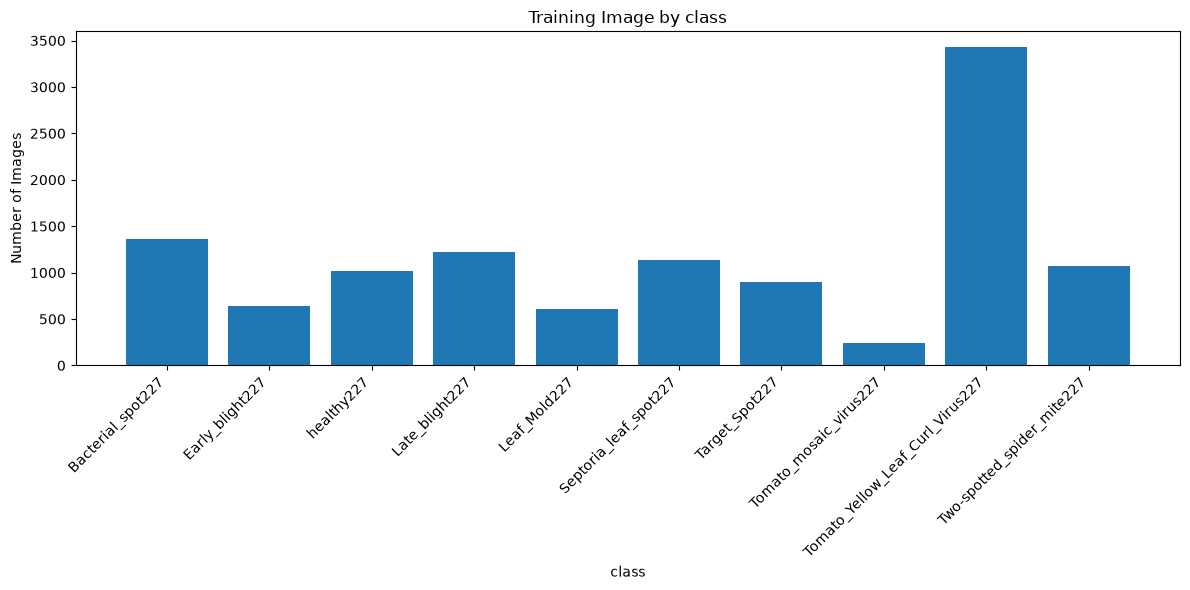

In [8]:
plt.figure(figsize=(12,6))
plt.bar(
    train_counts.keys(),
    train_counts.values()
)
plt.title("Training Image by class")
plt.xlabel("class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45,ha="right")
plt.tight_layout()
plt.show()

In [10]:
max_class=max(train_counts.values())
min_class=min(train_counts.values())
imbalance_ratio=max_class/min_class
print("Largest class: ",max(train_counts,key=train_counts.get))
print("Largest class images:",max_class)
print("Smallest class:",min(train_counts,key=train_counts.get))
print("Smallest class images:",min_class)
print(f"Imbalance ratio:{imbalance_ratio:2f}:1")

Largest class:  Tomato_Yellow_Leaf_Curl_Virus227
Largest class images: 3428
Smallest class: Tomato_mosaic_virus227
Smallest class images: 239
Imbalance ratio:14.343096:1


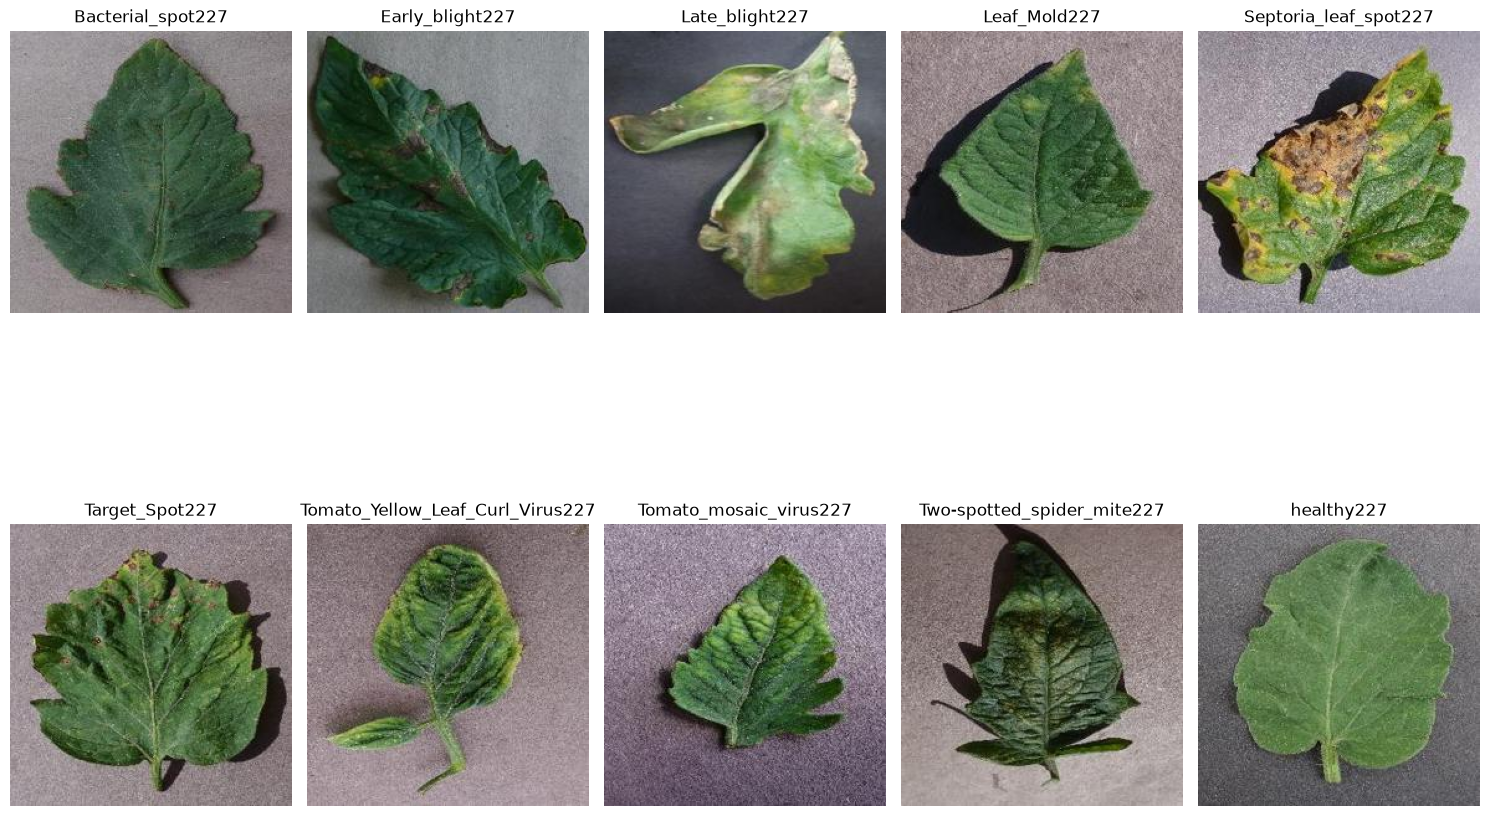

In [11]:
from PIL import Image
import random

plt.figure(figsize=(15, 12))

classes = sorted(train_counts.keys())

for i, class_name in enumerate(classes):
    class_dir = TRAIN_DIR / class_name
    
    image_files = [
        f for f in class_dir.iterdir()
        if f.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ]
    
    image_path = random.choice(image_files)
    image = Image.open(image_path)

    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
from collections import Counter

image_sizes = Counter()

for class_dir in TRAIN_DIR.iterdir():
    if class_dir.is_dir():
        for image_file in class_dir.iterdir():
            if image_file.suffix.lower() in [".jpg", ".jpeg", ".png"]:
                try:
                    with Image.open(image_file) as img:
                        image_sizes[img.size] += 1
                except Exception:
                    pass

print("Different image dimensions:", len(image_sizes))

print("\nMost common image dimensions:")
for size, count in image_sizes.most_common(10):
    print(f"{size}: {count} images")

Different image dimensions: 1

Most common image dimensions:
(227, 227): 11620 images


In [13]:
from PIL import Image

corrupted_images = []

for split_name, directory in [
    ("train", TRAIN_DIR),
    ("test", TEST_DIR)
]:
    for class_dir in directory.iterdir():
        if not class_dir.is_dir():
            continue

        for image_file in class_dir.iterdir():
            if image_file.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
                continue

            try:
                with Image.open(image_file) as img:
                    img.verify()
            except Exception:
                corrupted_images.append(
                    {
                        "split": split_name,
                        "class": class_dir.name,
                        "file": str(image_file)
                    }
                )

print("Corrupted images:", len(corrupted_images))

if corrupted_images:
    for item in corrupted_images[:10]:
        print(item)
else:
    print("No corrupted images found.")

Corrupted images: 0
No corrupted images found.


In [14]:
color_modes = {}

for class_dir in TRAIN_DIR.iterdir():
    if not class_dir.is_dir():
        continue

    for image_file in class_dir.iterdir():
        if image_file.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue

        try:
            with Image.open(image_file) as img:
                mode = img.mode
                color_modes[mode] = color_modes.get(mode, 0) + 1
        except Exception:
            pass

print("Image color modes:")

for mode, count in sorted(color_modes.items()):
    print(f"{mode}: {count}")

Image color modes:
RGB: 11620


In [17]:
widths = []
heights = []

for class_dir in TRAIN_DIR.iterdir():
    if not class_dir.is_dir():
        continue

    for image_file in class_dir.iterdir():
        if image_file.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue

        try:
            with Image.open(image_file) as img:
                width, height = img.size
                widths.append(width)
                heights.append(height)
        except Exception:
            pass

print("Number of images checked:", len(widths))

print("\nWidth:")
print("Minimum:", min(widths))
print("Maximum:", max(widths))
print("Average:", round(sum(widths) / len(widths), 2))

print("\nHeight:")
print("Minimum:", min(heights))
print("Maximum:", max(heights))
print("Average:", round(sum(heights) / len(heights), 2))

Number of images checked: 11620

Width:
Minimum: 227
Maximum: 227
Average: 227.0

Height:
Minimum: 227
Maximum: 227
Average: 227.0


In [16]:
color_modes = {}

for class_dir in TRAIN_DIR.iterdir():
    if not class_dir.is_dir():
        continue

    for image_file in class_dir.iterdir():
        if image_file.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue

        try:
            with Image.open(image_file) as img:
                mode = img.mode
                color_modes[mode] = color_modes.get(mode, 0) + 1
        except Exception:
            pass

print("Image color modes:")

for mode, count in sorted(color_modes.items()):
    print(f"{mode}: {count}")

Image color modes:
RGB: 11620


In [15]:
summary = pd.DataFrame({
    "class": list(train_counts.keys()),
    "train_images": list(train_counts.values()),
    "test_images": [
        test_counts[class_name]
        for class_name in train_counts.keys()
    ]
})

summary["total_images"] = (
    summary["train_images"] +
    summary["test_images"]
)

summary["train_percentage"] = (
    summary["train_images"] /
    summary["train_images"].sum() * 100
).round(2)

summary["test_percentage"] = (
    summary["test_images"] /
    summary["test_images"].sum() * 100
).round(2)

summary = summary.sort_values(
    "train_images",
    ascending=False
).reset_index(drop=True)

summary

,class,train_images,test_images,total_images,train_percentage,test_percentage
0,Tomato_Yellow_Leaf_Curl_Virus227,3428,858,4286,29.50,29.47
1,Bacterial_spot227,1361,341,1702,11.71,11.71
2,Late_blight227,1222,306,1528,10.52,10.51
3,Septoria_leaf_spot227,1133,284,1417,9.75,9.76
4,Two-spotted_spider_mite227,1072,269,1341,9.23,9.24
5,healthy227,1017,255,1272,8.75,8.76
6,Target_Spot227,899,225,1124,7.74,7.73
7,Early_blight227,640,160,800,5.51,5.50
8,Leaf_Mold227,609,153,762,5.24,5.26
9,Tomato_mosaic_virus227,239,60,299,2.06,2.06


In [18]:
from collections import Counter

all_filenames = []

for split_dir in [TRAIN_DIR, TEST_DIR]:
    for class_dir in split_dir.iterdir():
        if not class_dir.is_dir():
            continue

        for image_file in class_dir.iterdir():
            if image_file.suffix.lower() in [".jpg", ".jpeg", ".png"]:
                all_filenames.append(image_file.name)

filename_counts = Counter(all_filenames)

duplicates = {
    name: count
    for name, count in filename_counts.items()
    if count > 1
}

print("Total image files:", len(all_filenames))
print("Unique filenames:", len(filename_counts))
print("Duplicate filenames:", len(duplicates))

if duplicates:
    print("\nFirst 10 duplicates:")
    for name, count in list(duplicates.items())[:10]:
        print(name, "->", count)
else:
    print("No duplicate filenames found.")

Total image files: 14531
Unique filenames: 14531
Duplicate filenames: 0
No duplicate filenames found.


In [20]:
summary = pd.DataFrame({
    "class": list(train_counts.keys()),
    "train_images": list(train_counts.values()),
    "test_images": [
        test_counts[class_name]
        for class_name in train_counts.keys()
    ]
})

summary["total_images"] = (
    summary["train_images"] +
    summary["test_images"]
)

summary["train_percentage"] = (
    summary["train_images"] /
    summary["train_images"].sum() * 100
).round(2)

summary["test_percentage"] = (
    summary["test_images"] /
    summary["test_images"].sum() * 100
).round(2)

summary = summary.sort_values(
    "train_images",
    ascending=False
).reset_index(drop=True)

summary

,class,train_images,test_images,total_images,train_percentage,test_percentage
0,Tomato_Yellow_Leaf_Curl_Virus227,3428,858,4286,29.50,29.47
1,Bacterial_spot227,1361,341,1702,11.71,11.71
2,Late_blight227,1222,306,1528,10.52,10.51
3,Septoria_leaf_spot227,1133,284,1417,9.75,9.76
4,Two-spotted_spider_mite227,1072,269,1341,9.23,9.24
5,healthy227,1017,255,1272,8.75,8.76
6,Target_Spot227,899,225,1124,7.74,7.73
7,Early_blight227,640,160,800,5.51,5.50
8,Leaf_Mold227,609,153,762,5.24,5.26
9,Tomato_mosaic_virus227,239,60,299,2.06,2.06


In [22]:
import tensorflow as tf
from pathlib import Path

print("TensorFlow version:", tf.__version__)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Seed:", SEED)

TensorFlow version: 2.21.0
Image size: (224, 224)
Batch size: 32
Seed: 42


In [23]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

print("Training batches:", tf.data.experimental.cardinality(train_dataset).numpy())
print("Validation batches:", tf.data.experimental.cardinality(validation_dataset).numpy())

Found 11620 files belonging to 10 classes.
Using 9296 files for training.
Found 11620 files belonging to 10 classes.
Using 2324 files for validation.
Training batches: 291
Validation batches: 73


In [24]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="int"
)

class_names = train_dataset.class_names

print("Number of classes:", len(class_names))
print("\nClasses:")

for index, class_name in enumerate(class_names):
    print(index, "->", class_name)

Found 2911 files belonging to 10 classes.
Number of classes: 10

Classes:
0 -> Bacterial_spot227
1 -> Early_blight227
2 -> Late_blight227
3 -> Leaf_Mold227
4 -> Septoria_leaf_spot227
5 -> Target_Spot227
6 -> Tomato_Yellow_Leaf_Curl_Virus227
7 -> Tomato_mosaic_virus227
8 -> Two-spotted_spider_mite227
9 -> healthy227


In [25]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.10),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10),
], name="data_augmentation")

print(data_augmentation)

<Sequential name=data_augmentation, built=False>


In [26]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

print("Dataset pipeline optimization complete.")

Dataset pipeline optimization complete.


In [28]:
for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Image data type:", images.dtype)
    print("Minimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image data type: <dtype: 'float32'>
Minimum pixel value: 0.0
Maximum pixel value: 242.02783


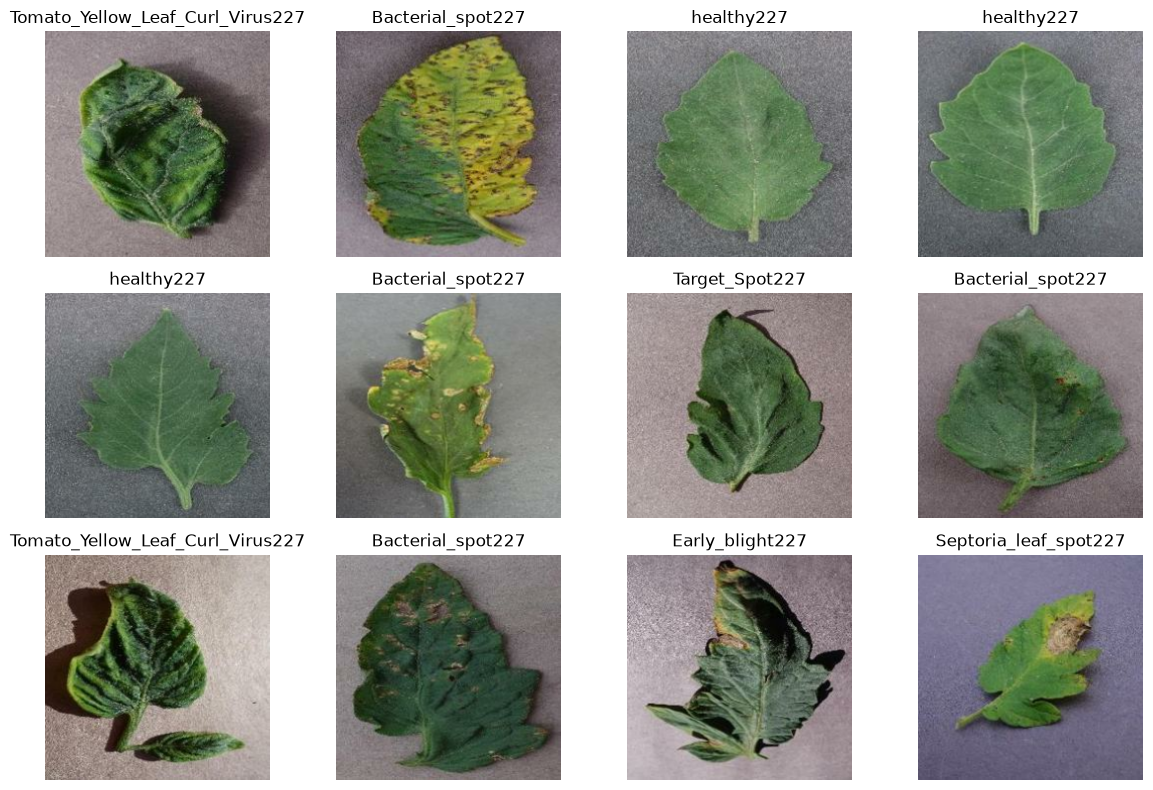

In [29]:
plt.figure(figsize=(12, 8))

for images, labels in train_dataset.take(1):
    for i in range(12):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")

plt.tight_layout()
plt.show()

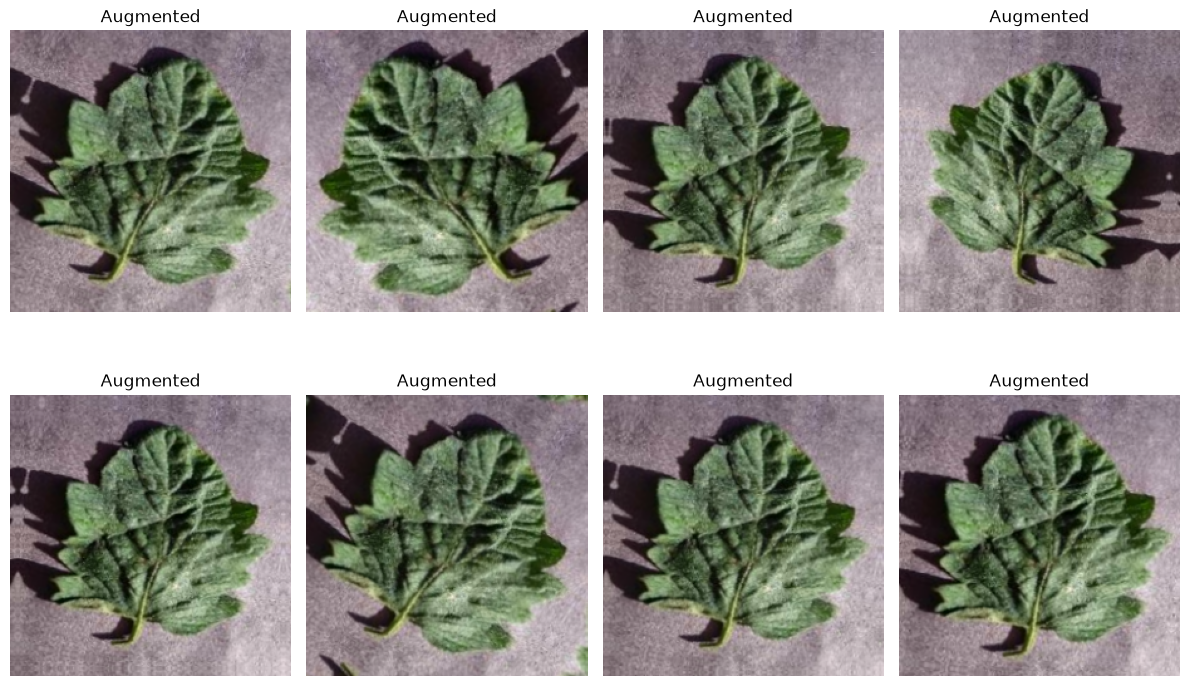

In [30]:
plt.figure(figsize=(12, 8))

for images, labels in train_dataset.take(1):
    sample_image = images[0]

    for i in range(8):
        augmented_image = data_augmentation(
            tf.expand_dims(sample_image, 0),
            training=True
        )[0]

        plt.subplot(2, 4, i + 1)
        plt.imshow(
            tf.clip_by_value(
                augmented_image,
                0,
                255
            ).numpy().astype("uint8")
        )
        plt.title("Augmented")
        plt.axis("off")

plt.tight_layout()
plt.show()

In [31]:
baseline_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    tf.keras.layers.Rescaling(1.0 / 255),

    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        len(class_names),
        activation="softmax"
    )
])

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,250 (42.61 MB)

 Trainable params: 11,170,250 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
print("Baseline CNN compiled successfully")

Baseline CNN compiled successfully


In [35]:
from pathlib import Path

checkpoint_path = Path("../models/baseline_cnn_best.keras")

checkpoint_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(checkpoint_path),
        monitor="val_loss",
        save_best_only=True
    )
]

print("Callbacks configured.")
print("Checkpoint:", checkpoint_path.resolve())

Callbacks configured.
Checkpoint: C:\Project\Data Science\Tomato Leaf Disease Detection\models\baseline_cnn_best.keras


In [36]:
baseline_history = baseline_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15


c:\Project\Data Science\Tomato Leaf Disease Detection\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


291/291 ━━━━━━━━━━━━━━━━━━━━ 1323s 4s/step - accuracy: 0.5041 - loss: 1.4523 - val_accuracy: 0.7078 - val_loss: 0.8513
Epoch 2/15
291/291 ━━━━━━━━━━━━━━━━━━━━ 751s 3s/step - accuracy: 0.6762 - loss: 0.9333 - val_accuracy: 0.8231 - val_loss: 0.5452
Epoch 3/15
291/291 ━━━━━━━━━━━━━━━━━━━━ 4515s 16s/step - accuracy: 0.7377 - loss: 0.7571 - val_accuracy: 0.7620 - val_loss: 0.6623
Epoch 4/15
291/291 ━━━━━━━━━━━━━━━━━━━━ 703s 2s/step - accuracy: 0.7792 - loss: 0.6466 - val_accuracy: 0.7973 - val_loss: 0.6083
Epoch 5/15
291/291 ━━━━━━━━━━━━━━━━━━━━ 709s 2s/step - accuracy: 0.8079 - loss: 0.5633 - val_accuracy: 0.8791 - val_loss: 0.3290
Epoch 6/15
291/291 ━━━━━━━━━━━━━━━━━━━━ 5275s 18s/step - accuracy: 0.8194 - loss: 0.5355 - val_accuracy: 0.8623 - val_loss: 0.3830
Epoch 7/15
291/291 ━━━━━━━━━━━━━━━━━━━━ 632s 2s/step - accuracy: 0.8336 - loss: 0.4900 - val_accuracy: 0.8546 - val_loss: 0.4427
Epoch 8/15
291/291 ━━━━━━━━━━━━━━━━━━━━ 633s 2s/step - accuracy: 0.8399 - loss: 0.4645 - val_accuracy: 

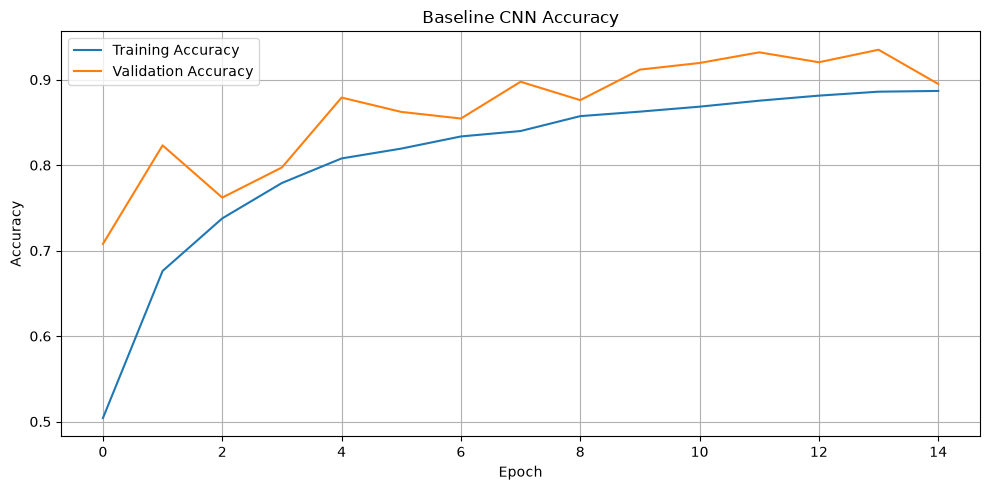

In [37]:
plt.figure(figsize=(10, 5))

plt.plot(
    baseline_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    baseline_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Baseline CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

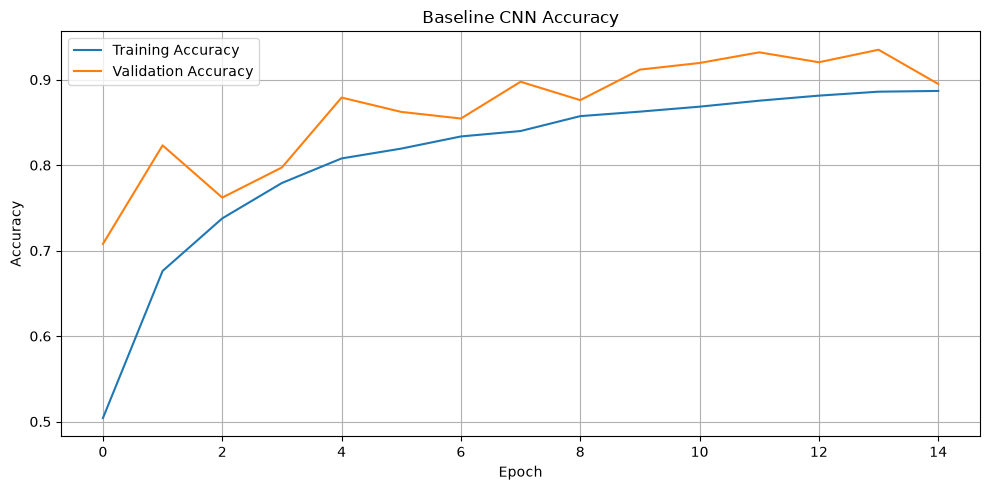

In [38]:
plt.figure(figsize=(10, 5))

plt.plot(
    baseline_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    baseline_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Baseline CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [39]:
test_loss, test_accuracy = baseline_model.evaluate(
    test_dataset,
    verbose=1
)

print("\nBaseline CNN Test Results")
print("========================")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

91/91 ━━━━━━━━━━━━━━━━━━━━ 86s 812ms/step - accuracy: 0.9313 - loss: 0.2107

Baseline CNN Test Results
Test Loss: 0.2107
Test Accuracy: 0.9313
Test Accuracy: 93.13%


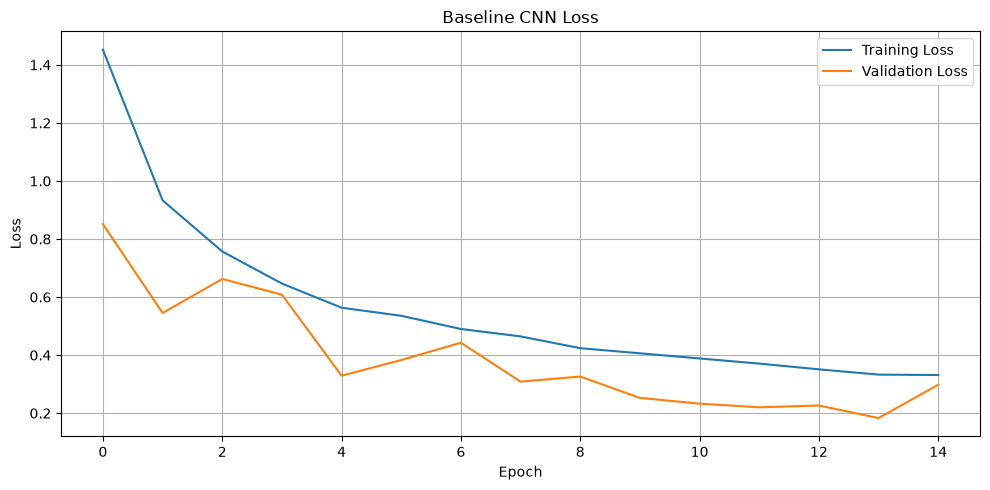

In [40]:
plt.figure(figsize=(10, 5))

plt.plot(
    baseline_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    baseline_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Baseline CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

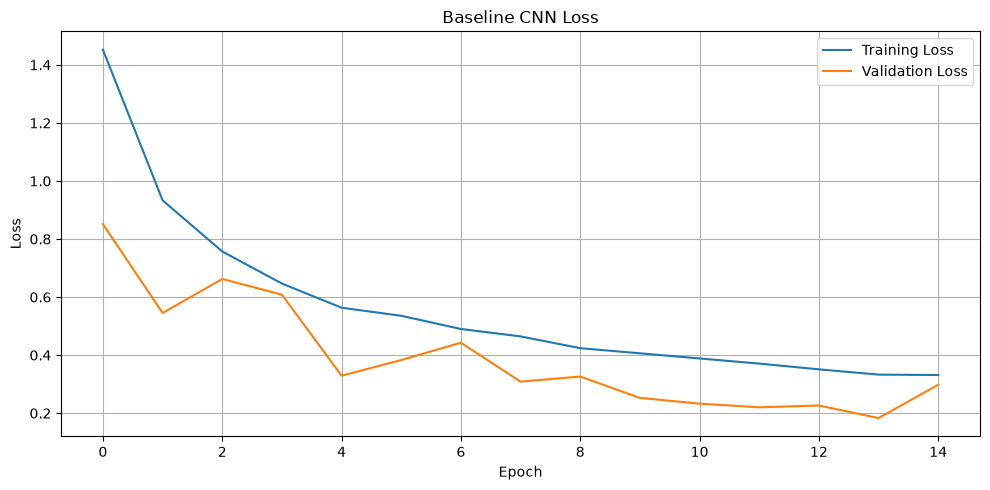

In [41]:
plt.figure(figsize=(10, 5))

plt.plot(
    baseline_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    baseline_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Baseline CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [42]:
test_loss, test_accuracy = baseline_model.evaluate(
    test_dataset,
    verbose=1
)

print("\nBaseline CNN Test Results")
print("=========================")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

91/91 ━━━━━━━━━━━━━━━━━━━━ 80s 866ms/step - accuracy: 0.9313 - loss: 0.2107

Baseline CNN Test Results
Test Loss: 0.2107
Test Accuracy: 0.9313
Test Accuracy: 93.13%


In [43]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_dataset.prefetch(AUTOTUNE)
val_ds = validation_dataset.prefetch(AUTOTUNE)
test_ds = test_dataset.prefetch(AUTOTUNE)

print("Dataset pipeline optimized.")

Dataset pipeline optimized.


In [48]:
mobile_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    tf.keras.layers.Lambda(
        tf.keras.applications.mobilenet_v2.preprocess_input
    ),

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        len(class_names),
        activation="softmax"
    )
])

mobile_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [49]:
mobile_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("MobileNetV2 model compiled successfully.")

MobileNetV2 model compiled successfully.


In [50]:
trainable_params = sum(
    tf.keras.backend.count_params(weight)
    for weight in mobile_model.trainable_weights
)

non_trainable_params = sum(
    tf.keras.backend.count_params(weight)
    for weight in mobile_model.non_trainable_weights
)

print("Trainable parameters:", trainable_params)
print("Non-trainable parameters:", non_trainable_params)

Trainable parameters: 12810
Non-trainable parameters: 2257984


In [51]:
from pathlib import Path

mobile_checkpoint = Path("../models/mobilenetv2_best.keras")

mobile_checkpoint.parent.mkdir(
    parents=True,
    exist_ok=True
)

mobile_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(mobile_checkpoint),
        monitor="val_loss",
        save_best_only=True
    )
]

print("MobileNetV2 callbacks ready.")
print("Checkpoint:", mobile_checkpoint.resolve())

MobileNetV2 callbacks ready.
Checkpoint: C:\Project\Data Science\Tomato Leaf Disease Detection\models\mobilenetv2_best.keras


In [52]:
from pathlib import Path

mobile_checkpoint = Path("../models/mobilenetv2_best.keras")

mobile_checkpoint.parent.mkdir(
    parents=True,
    exist_ok=True
)

mobile_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(mobile_checkpoint),
        monitor="val_loss",
        save_best_only=True
    )
]

print("MobileNetV2 callbacks ready.")
print("Checkpoint:", mobile_checkpoint.resolve())

MobileNetV2 callbacks ready.
Checkpoint: C:\Project\Data Science\Tomato Leaf Disease Detection\models\mobilenetv2_best.keras


In [55]:
mobile_history = mobile_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=mobile_callbacks
)

Epoch 1/8
291/291 ━━━━━━━━━━━━━━━━━━━━ 703s 2s/step - accuracy: 0.3621 - loss: 1.9222 - val_accuracy: 0.6149 - val_loss: 1.3356
Epoch 2/8
291/291 ━━━━━━━━━━━━━━━━━━━━ 467s 2s/step - accuracy: 0.5710 - loss: 1.3170 - val_accuracy: 0.7096 - val_loss: 1.0273
Epoch 3/8
291/291 ━━━━━━━━━━━━━━━━━━━━ 415s 1s/step - accuracy: 0.6579 - loss: 1.0676 - val_accuracy: 0.7504 - val_loss: 0.8786
Epoch 4/8
291/291 ━━━━━━━━━━━━━━━━━━━━ 358s 1s/step - accuracy: 0.7104 - loss: 0.9203 - val_accuracy: 0.7642 - val_loss: 0.7803
Epoch 5/8
291/291 ━━━━━━━━━━━━━━━━━━━━ 381s 1s/step - accuracy: 0.7245 - loss: 0.8491 - val_accuracy: 0.7806 - val_loss: 0.7112
Epoch 6/8
291/291 ━━━━━━━━━━━━━━━━━━━━ 438s 2s/step - accuracy: 0.7528 - loss: 0.7735 - val_accuracy: 0.7896 - val_loss: 0.6695
Epoch 7/8
291/291 ━━━━━━━━━━━━━━━━━━━━ 418s 1s/step - accuracy: 0.7700 - loss: 0.7177 - val_accuracy: 0.7969 - val_loss: 0.6327
Epoch 8/8
291/291 ━━━━━━━━━━━━━━━━━━━━ 450s 2s/step - accuracy: 0.7799 - loss: 0.6798 - val_accuracy: 0.

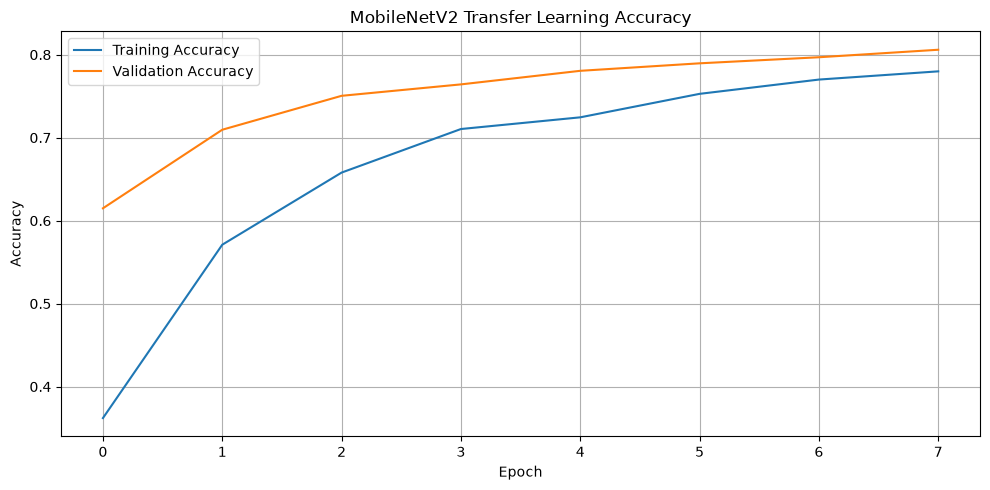

In [56]:
plt.figure(figsize=(10, 5))

plt.plot(
    mobile_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    mobile_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("MobileNetV2 Transfer Learning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

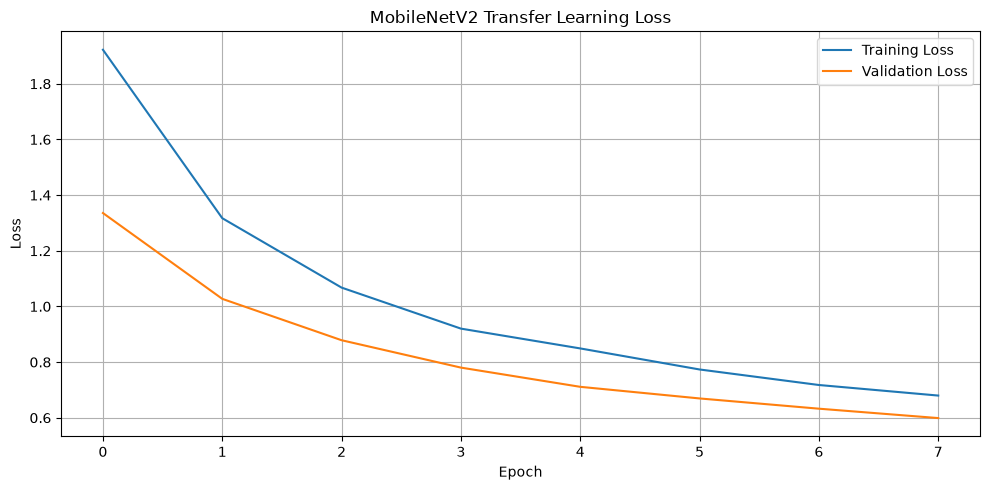

In [57]:
plt.figure(figsize=(10, 5))

plt.plot(
    mobile_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    mobile_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("MobileNetV2 Transfer Learning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

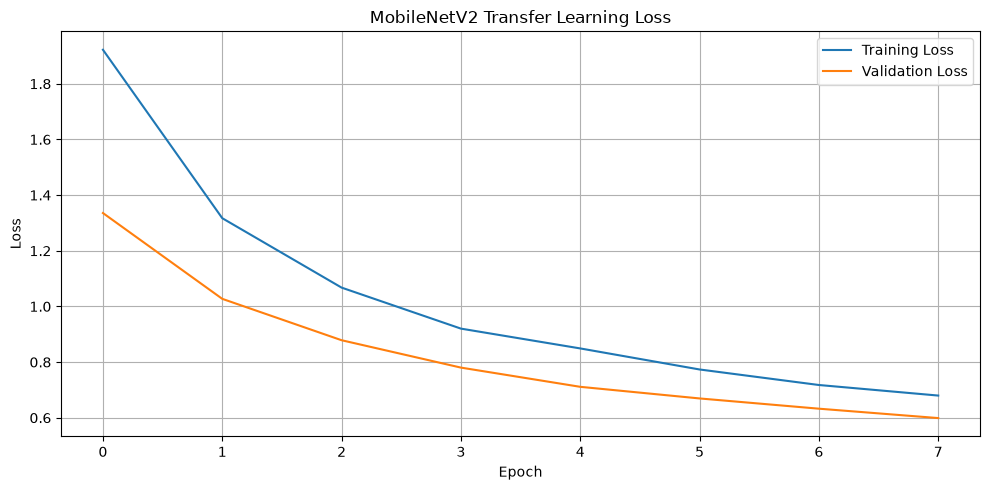

In [58]:
plt.figure(figsize=(10, 5))

plt.plot(
    mobile_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    mobile_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("MobileNetV2 Transfer Learning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [59]:
mobile_test_loss, mobile_test_accuracy = mobile_model.evaluate(
    test_ds,
    verbose=1
)

print("\nMobileNetV2 Test Results")
print("=======================")
print(f"Test Loss: {mobile_test_loss:.4f}")
print(f"Test Accuracy: {mobile_test_accuracy:.4f}")
print(f"Test Accuracy: {mobile_test_accuracy * 100:.2f}%")

91/91 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.8169 - loss: 0.5868

MobileNetV2 Test Results
Test Loss: 0.5868
Test Accuracy: 0.8169
Test Accuracy: 81.69%


In [61]:
import tensorflow as tf
from pathlib import Path
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

MODEL_PATH = Path("../models/mobilenetv2_best.keras")

fine_tune_model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={
        "preprocess_input": preprocess_input
    },
    safe_mode=False
)

print("MobileNetV2 model loaded successfully.")
print("Total layers:", len(fine_tune_model.layers))

MobileNetV2 model loaded successfully.
Total layers: 6


In [63]:
for i, layer in enumerate(fine_tune_model.layers):
    print(
        i,
        layer.name,
        "|",
        type(layer).__name__,
        "| trainable:",
        layer.trainable
    )

0 data_augmentation | Sequential | trainable: True
1 lambda | Lambda | trainable: True
2 mobilenetv2_1.00_224 | Functional | trainable: False
3 global_average_pooling2d | GlobalAveragePooling2D | trainable: True
4 dropout_1 | Dropout | trainable: True
5 dense_2 | Dense | trainable: True


In [ ]:
for i, layer in enumerate(fine_tune_model.layers):
    if isinstance(layer, tf.keras.Model):
        print("Base model found:")
        print("Index:", i)
        print("Name:", layer.name)
        print("Layers:", len(layer.layers))
        

Base model found:
Index: 0
Name: data_augmentation
Layers: 4
Base model found:
Index: 2
Name: mobilenetv2_1.00_224
Layers: 154


In [65]:
base_model = None

for layer in fine_tune_model.layers:
    if isinstance(layer, tf.keras.Model):
        base_model = layer
        break

if base_model is not None:
    print("Base model:", base_model.name)
    print("Total base layers:", len(base_model.layers))
    print("Trainable layers:", sum(layer.trainable for layer in base_model.layers))
else:
    print("Base model not found.")

Base model: data_augmentation
Total base layers: 4
Trainable layers: 4


In [66]:
base_model.trainable = True

# Freeze most of MobileNetV2
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Keep the final 30 layers trainable
for layer in base_model.layers[-30:]:
    layer.trainable = True

print("Fine-tuning configuration ready.")
print(
    "Trainable base layers:",
    sum(layer.trainable for layer in base_model.layers)
)
print(
    "Total base layers:",
    len(base_model.layers)
)

Fine-tuning configuration ready.
Trainable base layers: 4
Total base layers: 4


In [67]:
fine_tune_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fine-tuning model compiled successfully.")

Fine-tuning model compiled successfully.


In [69]:
fine_tune_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "../models/mobilenetv2_finetuned_best.keras",
        monitor="val_accuracy",
        save_best_only=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=1,
        min_lr=1e-7
    )
]

fine_tune_history = fine_tune_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=fine_tune_callbacks
)

print("Fine-tuning completed.")

Epoch 1/5
291/291 ━━━━━━━━━━━━━━━━━━━━ 477s 2s/step - accuracy: 0.7927 - loss: 0.6570 - val_accuracy: 0.8111 - val_loss: 0.5910 - learning_rate: 1.0000e-05
Epoch 2/5
291/291 ━━━━━━━━━━━━━━━━━━━━ 428s 1s/step - accuracy: 0.7935 - loss: 0.6462 - val_accuracy: 0.8137 - val_loss: 0.5861 - learning_rate: 1.0000e-05
Epoch 3/5
291/291 ━━━━━━━━━━━━━━━━━━━━ 20619s 71s/step - accuracy: 0.7884 - loss: 0.6601 - val_accuracy: 0.8141 - val_loss: 0.5841 - learning_rate: 1.0000e-05
Epoch 4/5
291/291 ━━━━━━━━━━━━━━━━━━━━ 503s 2s/step - accuracy: 0.7944 - loss: 0.6473 - val_accuracy: 0.8133 - val_loss: 0.5826 - learning_rate: 1.0000e-05
Epoch 5/5
291/291 ━━━━━━━━━━━━━━━━━━━━ 484s 2s/step - accuracy: 0.7944 - loss: 0.6388 - val_accuracy: 0.8145 - val_loss: 0.5794 - learning_rate: 1.0000e-05
Fine-tuning completed.


In [70]:
# Evaluate the fine-tuned model on the test set

fine_tune_test_loss, fine_tune_test_accuracy = fine_tune_model.evaluate(
    test_ds,
    verbose=1
)

print("\nFine-Tuned MobileNetV2 Test Results")
print("===================================")
print(f"Test Loss: {fine_tune_test_loss:.4f}")
print(f"Test Accuracy: {fine_tune_test_accuracy:.4f}")
print(f"Test Accuracy: {fine_tune_test_accuracy * 100:.2f}%")

91/91 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.8200 - loss: 0.5687

Fine-Tuned MobileNetV2 Test Results
Test Loss: 0.5687
Test Accuracy: 0.8200
Test Accuracy: 82.00%


In [73]:
# Recalculate test accuracy for existing trained models
# This does NOT train the models again.

baseline_test_loss, baseline_test_accuracy = baseline_model.evaluate(
    test_ds,
    verbose=1
)

mobile_test_loss, mobile_test_accuracy = mobile_model.evaluate(
    test_ds,
    verbose=1
)

print("\nBaseline CNN Accuracy:")
print(f"{baseline_test_accuracy * 100:.2f}%")

print("\nMobileNetV2 Accuracy:")
print(f"{mobile_test_accuracy * 100:.2f}%")

print("\nFine-Tuned MobileNetV2 Accuracy:")
print(f"{fine_tune_test_accuracy * 100:.2f}%")

91/91 ━━━━━━━━━━━━━━━━━━━━ 42s 453ms/step - accuracy: 0.9313 - loss: 0.2107
91/91 ━━━━━━━━━━━━━━━━━━━━ 89s 964ms/step - accuracy: 0.8169 - loss: 0.5868

Baseline CNN Accuracy:
93.13%

MobileNetV2 Accuracy:
81.69%

Fine-Tuned MobileNetV2 Accuracy:
82.00%


In [74]:
# Model comparison

model_comparison = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "MobileNetV2",
        "Fine-Tuned MobileNetV2"
    ],
    "Test Accuracy (%)": [
        baseline_test_accuracy * 100,
        mobile_test_accuracy * 100,
        fine_tune_test_accuracy * 100
    ]
})

model_comparison = model_comparison.sort_values(
    by="Test Accuracy (%)",
    ascending=False
).reset_index(drop=True)

model_comparison

,Model,Test Accuracy (%)
0,Baseline CNN,93.129510
1,Fine-Tuned MobileNetV2,81.999314
2,MobileNetV2,81.690139


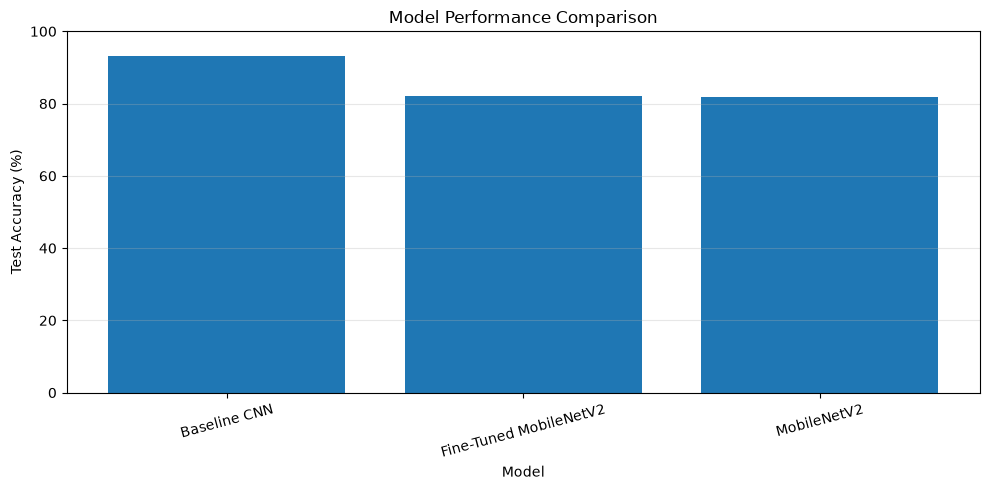

In [75]:
plt.figure(figsize=(10, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["Test Accuracy (%)"]
)

plt.ylabel("Test Accuracy (%)")
plt.xlabel("Model")
plt.title("Model Performance Comparison")
plt.ylim(0, 100)
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

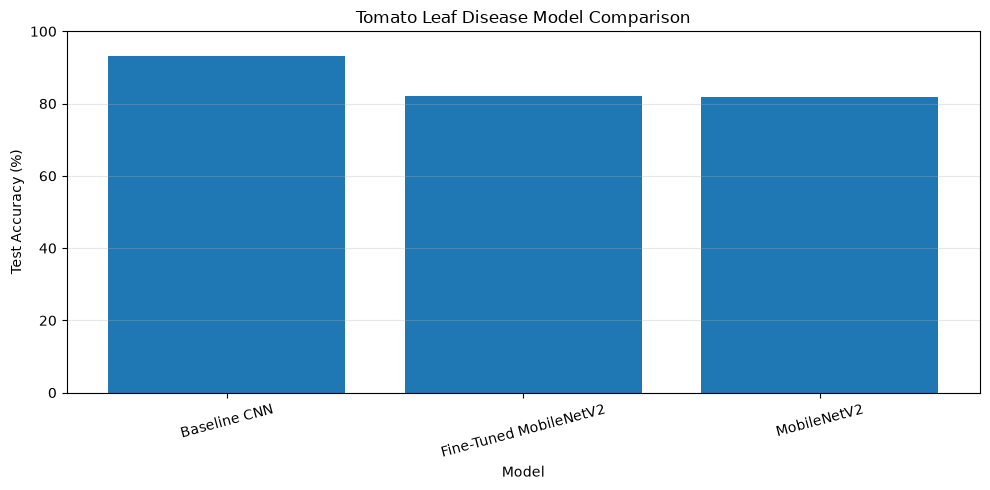

In [76]:
plt.figure(figsize=(10, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["Test Accuracy (%)"]
)

plt.ylabel("Test Accuracy (%)")
plt.xlabel("Model")
plt.title("Tomato Leaf Disease Model Comparison")
plt.ylim(0, 100)
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [78]:
import numpy as np
from sklearn.metrics import classification_report

# Get true labels and predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = baseline_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

# Classification report
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print("Baseline CNN Classification Report")
print("===================================")
print(report)

Baseline CNN Classification Report
                                  precision    recall  f1-score   support

               Bacterial_spot227     0.9521    0.9326    0.9422       341
                 Early_blight227     0.8239    0.8187    0.8213       160
                  Late_blight227     0.8765    0.9281    0.9016       306
                    Leaf_Mold227     0.9403    0.8235    0.8780       153
           Septoria_leaf_spot227     0.9466    0.8732    0.9084       284
                  Target_Spot227     0.8805    0.8844    0.8825       225
Tomato_Yellow_Leaf_Curl_Virus227     0.9757    0.9825    0.9791       858
          Tomato_mosaic_virus227     0.9649    0.9167    0.9402        60
      Two-spotted_spider_mite227     0.8873    0.9368    0.9114       269
                      healthy227     0.9551    1.0000    0.9770       255

                        accuracy                         0.9313      2911
                       macro avg     0.9203    0.9097    0.9142      2911
 

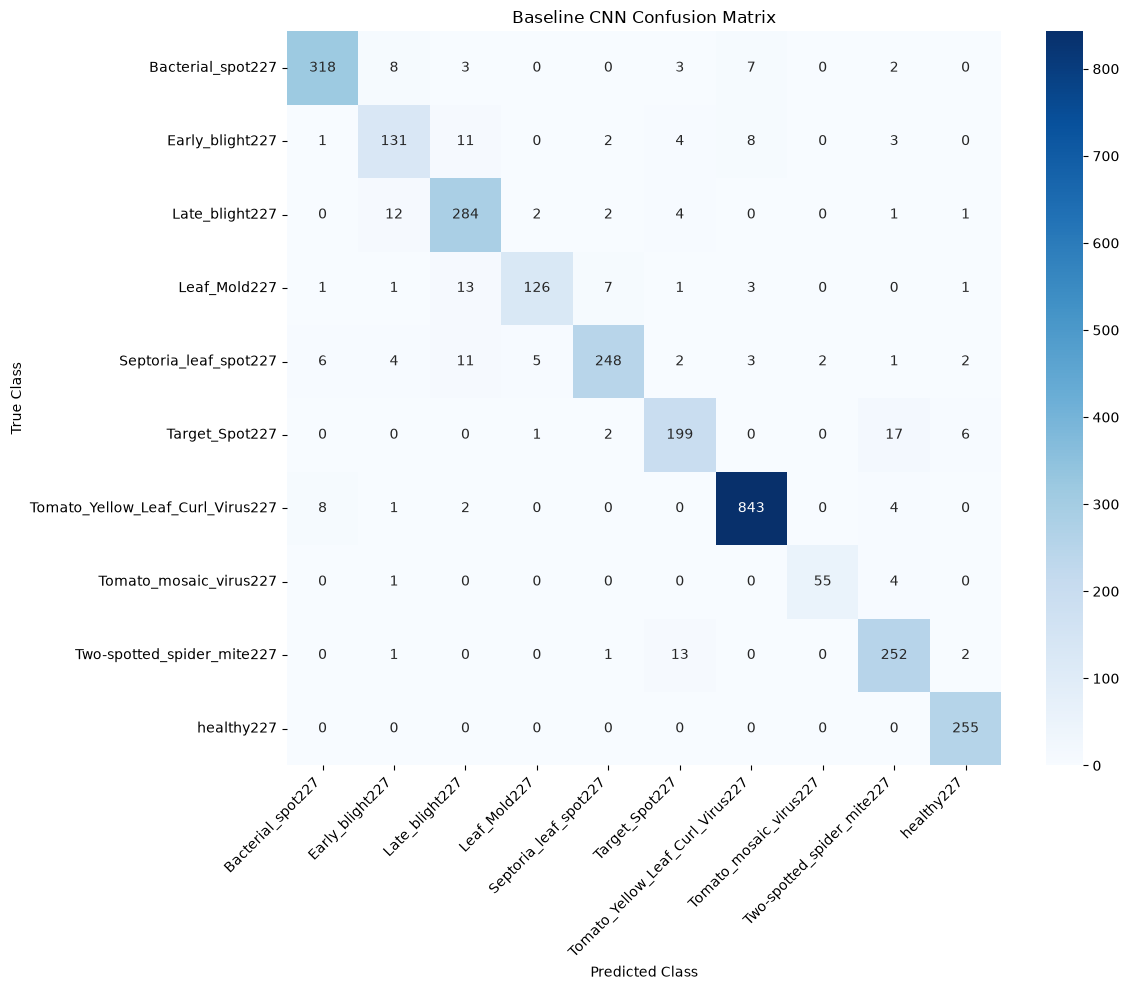

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Baseline CNN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [81]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report

# Load fine-tuned MobileNetV2
MODEL_PATH = Path("../models/mobilenetv2_finetuned_best.keras")

fine_tuned_model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={
        "preprocess_input": tf.keras.applications.mobilenet_v2.preprocess_input
    },
    safe_mode=False
)

print("Fine-Tuned MobileNetV2 model loaded successfully.")

# Get true labels and predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = fine_tuned_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

# Classification report
fine_tuned_report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print("Fine-Tuned MobileNetV2 Classification Report")
print("=" * 50)
print(fine_tuned_report)

Fine-Tuned MobileNetV2 model loaded successfully.
Fine-Tuned MobileNetV2 Classification Report
                                  precision    recall  f1-score   support

               Bacterial_spot227     0.7188    0.8768    0.7900       341
                 Early_blight227     0.6429    0.2250    0.3333       160
                  Late_blight227     0.9061    0.8203    0.8611       306
                    Leaf_Mold227     0.7425    0.8105    0.7750       153
           Septoria_leaf_spot227     0.7019    0.7711    0.7349       284
                  Target_Spot227     0.7068    0.6000    0.6490       225
Tomato_Yellow_Leaf_Curl_Virus227     0.9659    0.9569    0.9614       858
          Tomato_mosaic_virus227     0.9394    0.5167    0.6667        60
      Two-spotted_spider_mite227     0.7233    0.8550    0.7836       269
                      healthy227     0.8282    0.9451    0.8828       255

                        accuracy                         0.8200      2911
               

In [82]:
import numpy as np
from sklearn.metrics import classification_report

# Get true labels and predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = fine_tuned_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

# Classification report
fine_tuned_report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print("Fine-Tuned MobileNetV2 Classification Report")
print("=============================================")
print(fine_tuned_report)

Fine-Tuned MobileNetV2 Classification Report
                                  precision    recall  f1-score   support

               Bacterial_spot227     0.7188    0.8768    0.7900       341
                 Early_blight227     0.6429    0.2250    0.3333       160
                  Late_blight227     0.9061    0.8203    0.8611       306
                    Leaf_Mold227     0.7425    0.8105    0.7750       153
           Septoria_leaf_spot227     0.7019    0.7711    0.7349       284
                  Target_Spot227     0.7068    0.6000    0.6490       225
Tomato_Yellow_Leaf_Curl_Virus227     0.9659    0.9569    0.9614       858
          Tomato_mosaic_virus227     0.9394    0.5167    0.6667        60
      Two-spotted_spider_mite227     0.7233    0.8550    0.7836       269
                      healthy227     0.8282    0.9451    0.8828       255

                        accuracy                         0.8200      2911
                       macro avg     0.7876    0.7377    0.7438  

<Figure size 1200x1000 with 0 Axes>

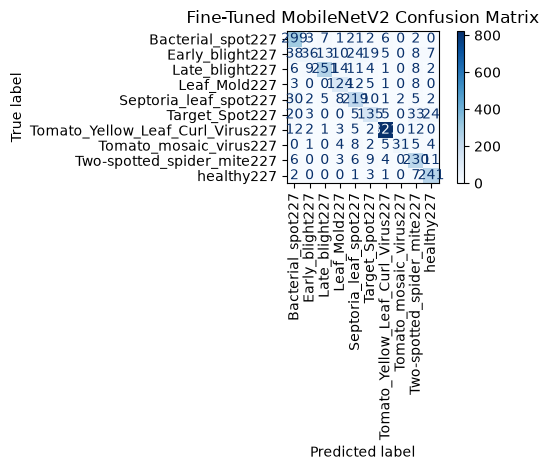

In [83]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = fine_tuned_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display confusion matrix
plt.figure(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    xticks_rotation=90,
    values_format="d"
)

plt.title("Fine-Tuned MobileNetV2 Confusion Matrix")
plt.tight_layout()
plt.show()

Generating predictions for confusion matrix...
Predictions completed.


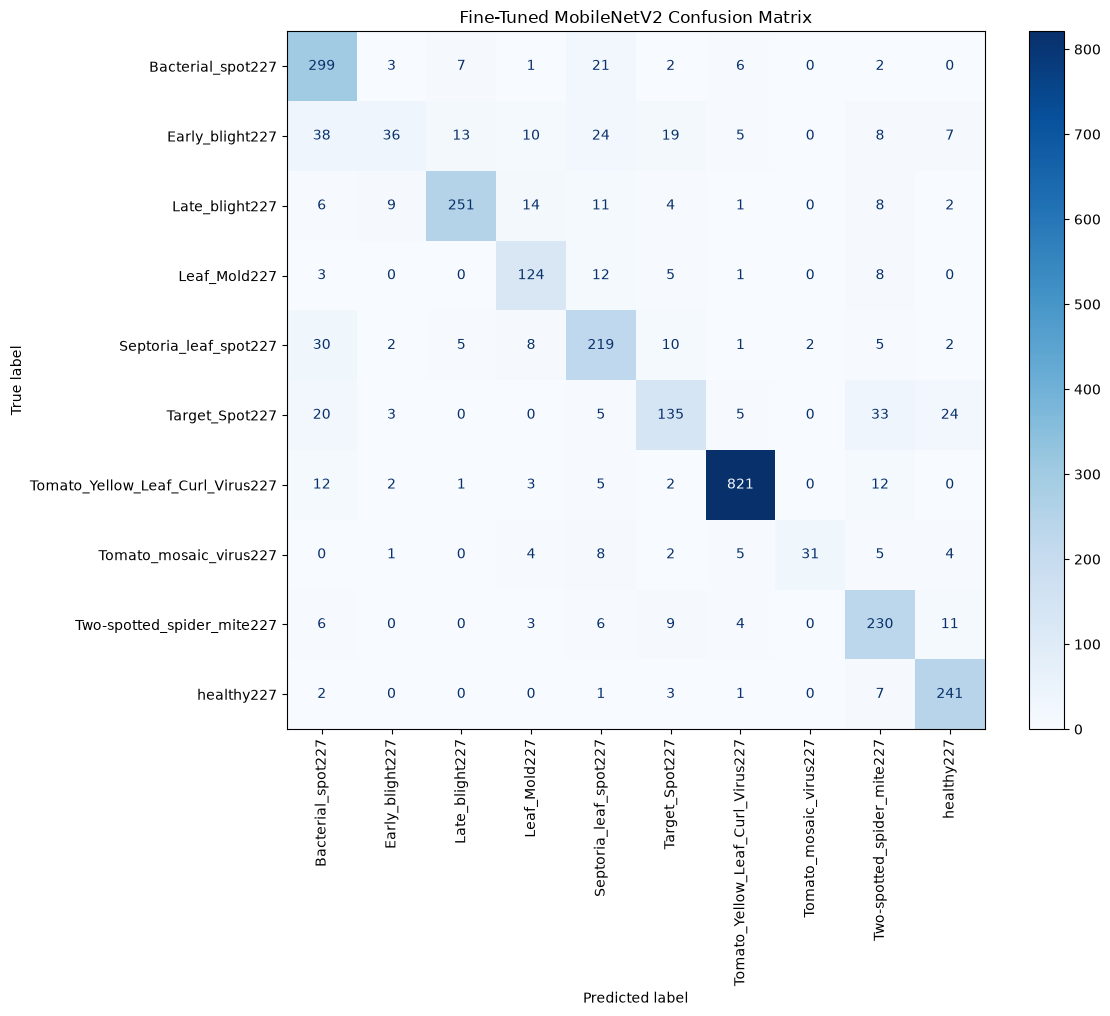

6.13 completed successfully.


In [84]:
# 6.13 - Fine-Tuned MobileNetV2 Confusion Matrix

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("Generating predictions for confusion matrix...")

y_true_ft = []
y_pred_ft = []

for images, labels in test_ds:
    predictions = fine_tuned_model.predict(images, verbose=0)

    y_true_ft.extend(labels.numpy())
    y_pred_ft.extend(np.argmax(predictions, axis=1))

print("Predictions completed.")

# Create confusion matrix
cm_ft = confusion_matrix(y_true_ft, y_pred_ft)

# Plot
fig, ax = plt.subplots(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_ft,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=90,
    values_format="d",
    colorbar=True
)

ax.set_title("Fine-Tuned MobileNetV2 Confusion Matrix")

plt.tight_layout()
plt.show()

print("6.13 completed successfully.")

Creating per-class performance summary...

Per-Class Performance:


,precision,recall,f1-score,support
Bacterial_spot227,0.7188,0.8768,0.7900,341.0
Early_blight227,0.6429,0.2250,0.3333,160.0
Late_blight227,0.9061,0.8203,0.8611,306.0
Leaf_Mold227,0.7425,0.8105,0.7750,153.0
Septoria_leaf_spot227,0.7019,0.7711,0.7349,284.0
Target_Spot227,0.7068,0.6000,0.6490,225.0
Tomato_Yellow_Leaf_Curl_Virus227,0.9659,0.9569,0.9614,858.0
Tomato_mosaic_virus227,0.9394,0.5167,0.6667,60.0
Two-spotted_spider_mite227,0.7233,0.8550,0.7836,269.0
healthy227,0.8282,0.9451,0.8828,255.0


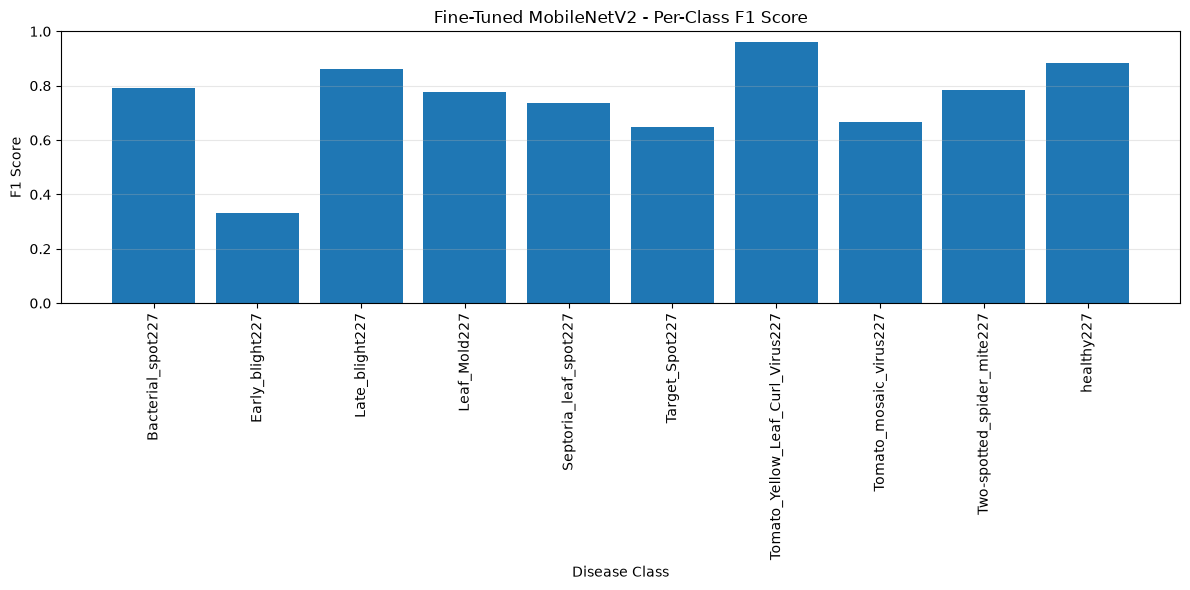

6.14 completed successfully.


In [85]:
# 6.14 - Per-Class F1 Score

import pandas as pd
import matplotlib.pyplot as plt

print("Creating per-class performance summary...")

# Convert classification report to dictionary
report_dict = classification_report(
    y_true_ft,
    y_pred_ft,
    target_names=class_names,
    output_dict=True
)

# Create DataFrame
class_performance = pd.DataFrame(report_dict).T

# Keep only actual classes
class_performance = class_performance.loc[class_names]

# Display table
print("\nPer-Class Performance:")
display(
    class_performance[
        ["precision", "recall", "f1-score", "support"]
    ].round(4)
)

# Plot F1 scores
plt.figure(figsize=(12, 6))

plt.bar(
    class_performance.index,
    class_performance["f1-score"]
)

plt.title("Fine-Tuned MobileNetV2 - Per-Class F1 Score")
plt.xlabel("Disease Class")
plt.ylabel("F1 Score")
plt.xticks(rotation=90)
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("6.14 completed successfully.")

Creating final model comparison...


,Model,Test Accuracy (%)
0,Baseline CNN,93.13
1,MobileNetV2,81.69
2,Fine-Tuned MobileNetV2,82.00



Model Performance Summary
Baseline CNN: 93.13%
MobileNetV2: 81.69%
Fine-Tuned MobileNetV2: 82.00%

Highest test accuracy in this comparison: Baseline CNN (93.13%)


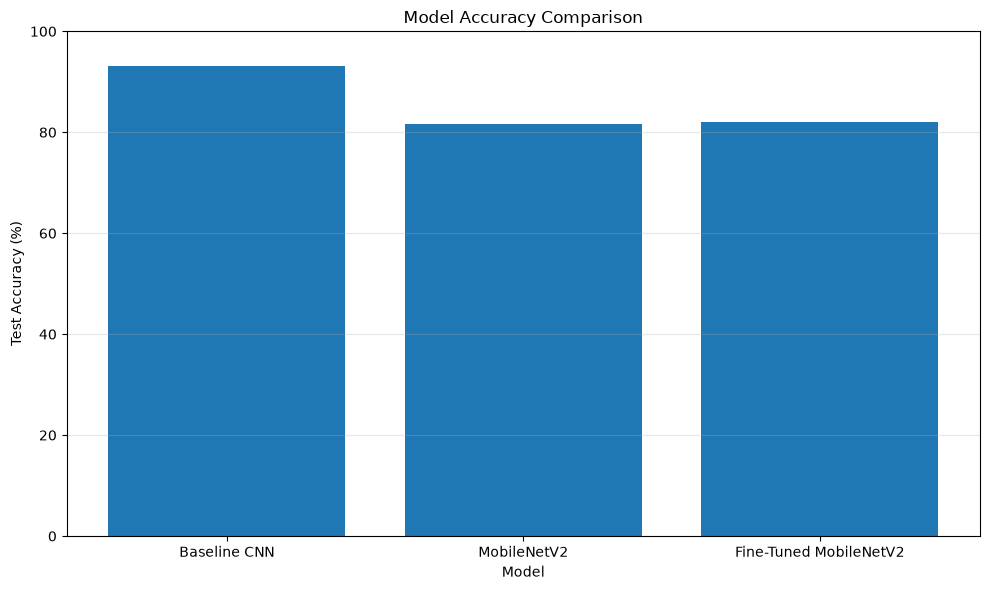


6.15 completed successfully.


In [86]:
# 6.15 - Final Model Comparison

import pandas as pd
import matplotlib.pyplot as plt

print("Creating final model comparison...")

# Model results obtained during testing
final_results = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "MobileNetV2",
        "Fine-Tuned MobileNetV2"
    ],
    "Test Accuracy (%)": [
        93.13,
        81.69,
        82.00
    ]
})

# Display results
display(final_results)

# Find highest accuracy
best_model = final_results.loc[
    final_results["Test Accuracy (%)"].idxmax()
]

print("\nModel Performance Summary")
print("=========================")

for _, row in final_results.iterrows():
    print(
        f"{row['Model']}: "
        f"{row['Test Accuracy (%)']:.2f}%"
    )

print(
    f"\nHighest test accuracy in this comparison: "
    f"{best_model['Model']} "
    f"({best_model['Test Accuracy (%)']:.2f}%)"
)

# Plot comparison
plt.figure(figsize=(10, 6))

plt.bar(
    final_results["Model"],
    final_results["Test Accuracy (%)"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("\n6.15 completed successfully.")

In [87]:
# 6.16 - Final Model Summary

import pandas as pd

final_model_summary = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "MobileNetV2",
        "Fine-Tuned MobileNetV2"
    ],
    "Test Accuracy": [
        93.13,
        81.69,
        82.00
    ]
})

final_model_summary["Test Accuracy"] = (
    final_model_summary["Test Accuracy"] / 100
)

final_model_summary["Test Accuracy (%)"] = (
    final_model_summary["Test Accuracy"] * 100
).round(2)

display(final_model_summary)

print("Final model evaluation summary created.")

,Model,Test Accuracy,Test Accuracy (%)
0,Baseline CNN,0.9313,93.13
1,MobileNetV2,0.8169,81.69
2,Fine-Tuned MobileNetV2,0.8200,82.00


Final model evaluation summary created.


In [88]:
# 6.17 - Select Production Model

production_model_name = "Baseline CNN"
production_accuracy = 93.13

print("Production Model")
print("================")
print(f"Model: {production_model_name}")
print(f"Test Accuracy: {production_accuracy:.2f}%")

Production Model
Model: Baseline CNN
Test Accuracy: 93.13%


In [89]:
# 6.17 - Select Production Model

production_model_name = "Baseline CNN"
production_accuracy = 93.13

print("Production Model")
print("================")
print(f"Model: {production_model_name}")
print(f"Test Accuracy: {production_accuracy:.2f}%")

Production Model
Model: Baseline CNN
Test Accuracy: 93.13%


In [90]:
# 6.19 - Save Class Names

import json
from pathlib import Path

CLASS_NAMES_PATH = Path("../models/class_names.json")

with open(CLASS_NAMES_PATH, "w", encoding="utf-8") as f:
    json.dump(
        class_names,
        f,
        indent=4,
        ensure_ascii=False
    )

print("Class names saved successfully.")
print(f"Location: {CLASS_NAMES_PATH.resolve()}")

print("\nClasses:")
for index, name in enumerate(class_names):
    print(f"{index}: {name}")

Class names saved successfully.
Location: C:\Project\Data Science\Tomato Leaf Disease Detection\models\class_names.json

Classes:
0: Bacterial_spot227
1: Early_blight227
2: Late_blight227
3: Leaf_Mold227
4: Septoria_leaf_spot227
5: Target_Spot227
6: Tomato_Yellow_Leaf_Curl_Virus227
7: Tomato_mosaic_virus227
8: Two-spotted_spider_mite227
9: healthy227
